# HITRAN Hapi spectrum generator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from hapi import *


%matplotlib widget

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Example Use

In [2]:
#First, we must choose a folder for our 'local database'
db_begin('HAPI_DB')


Using HAPI_DB

CH3OH
                     Lines parsed: 15234
CH3F
                     Lines parsed: 9069
CH4
                     Lines parsed: 200655
H20
                     Lines parsed: 58143
SO3_iso1_1.670-16.670um
                     Lines parsed: 3541
SO2
                     Lines parsed: 350816
SO2_iso1_1.670-16.670um
                     Lines parsed: 350816
SO
                     Lines parsed: 40527
H2S_iso1_1.670-16.670um
                     Lines parsed: 67541
OCS
                     Lines parsed: 459210
C4H2
                     Lines parsed: 162450
C2H6
                     Lines parsed: 52648
SO3
                     Lines parsed: 3541
CH3I
                     Lines parsed: 178247
C2H4
                     Lines parsed: 59536
CH3CN
                     Lines parsed: 11459
H2O
                     Lines parsed: 214627
CO2
                     Lines parsed: 132426
CS
                     Lines parsed: 593
CS2
                     Lines parsed: 280983
H2S
          

# Waterfall Plotting

## Helper functions

In [ ]:
# Extract base molecule name (strip extension and path, lowercase)
def extract_name(file):
    return os.path.splitext(os.path.basename(file))[0].lower().split('_')[0]

def plot_spectrum(molecule_name, ax_title):
    fetch(molecule_name, molecule_number_dict[molecule_name], 1, 600, 6000)    
    # wn_grid, coef = absorptionCoefficient_Voigt(
    #     SourceTables=molecule_name,
    #     WavenumberRange=(60, 600),
    #     WavenumberStep=0.01,
    #     Environment={'T': 296.0, 'p': 1.0}
    # )
    # wavelength_grid = 1e4 / wn_grid
    x, y = getStickXY(molecule_name)
    plt.plot(x, y, label = f'{molecule_name} Spectrum', alpha=0.5)

    return

# Helper function to map a molecule name to the right colormap
def get_colormap(mol):
    for key in target_molecules: # type: ignore
        if key in mol.replace("-", "").replace("_", ""):
            return target_molecules[key] # type: ignore
    # Default for everything else
    return red_orange_cmap # type: ignore

def get_wn_range_and_intensities(filepath):
    intensities = []
    with open(filepath, 'r') as f:
        first_line = f.readline()
        tokens = first_line.split()
        floats = []
        for t in tokens:
            try:
                floats.append(float(t))
            except:
                pass
        wn_start, wn_end = floats[0], floats[1]
        for line in f:
            for val in line.split():
                try:
                    intensity = float(val.replace('D','E'))
                    intensity = np.clip(intensity, 1e-25, None)  # avoid log(0)
                    intensities.append(intensity)
                except ValueError:
                    pass
    return wn_start, wn_end, np.array(intensities)

#  Function to load cross-section line by line data from a file

def load_cross_section_file(filepath):
    """
    For lbl files
    """
    data = np.genfromtxt(filepath, delimiter=' ', comments='#')
    wn_grid = data[:,0]
    intensities = data[:,1]
    wavelength_grid = 1e4 / wn_grid
    return wavelength_grid, intensities

def load_intensity_hapi(molecule_formula):
    """
    For HAPI database
    """
    nu = getColumn(molecule_formula, 'nu')  # Wavenumber in cm^-1
    intensity = getColumn(molecule_formula, 'sw')  # Intensity in cm/molecule
    wavelength = 1e4 / nu  # Convert to microns
    return wavelength, intensity

def generate_spectrum_hapi(table_name, molecule_number, wavelength_min, wavelength_max,
                           dwn=0.01, T=296.0, p=1.0):
    """
    Generates a gridded absorption coefficient spectrum using HAPI (Voigt).
    - dwn is the wavenumber step in cm^-1 (this is your *sampling*).
    - T in K, p in atm (HAPI convention).
    """
    isotopologue_number = 1

    wn_min = 1e4 / wavelength_max
    wn_max = 1e4 / wavelength_min

    # 1) download line list to a local HAPI table (does nothing if already present)
    fetch(table_name, molecule_number, isotopologue_number, wn_min, wn_max)

    # 2) compute absorption coefficient on a uniform wn grid
    wn_grid, coef = absorptionCoefficient_Voigt(
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={'T': T, 'p': p}
    )

    wavelength_grid = 1e4 / wn_grid
    return wavelength_grid, wn_grid, coef

### Input parameters

In [51]:
data_path = '/users/ZaniacCollins/Desktop/sgl/Python/HAPI_DB/'

#Wavelength range
wavelength_max = 16.6667
wavelength_min = 1.5

#This should correspond somehow to the resolution of the generated spectra
wavelength_bins = 200000


#list molecule names
molecule_number_dict = {'SO2': 9, 'OCS': 19, 'H2S': 31, 'SO3': 47, 'SO': 50, 'CS2': 53}

In [52]:
print(molecule_number_dict)

{'SO2': 9, 'OCS': 19, 'H2S': 31, 'SO3': 47, 'SO': 50, 'CS2': 53}


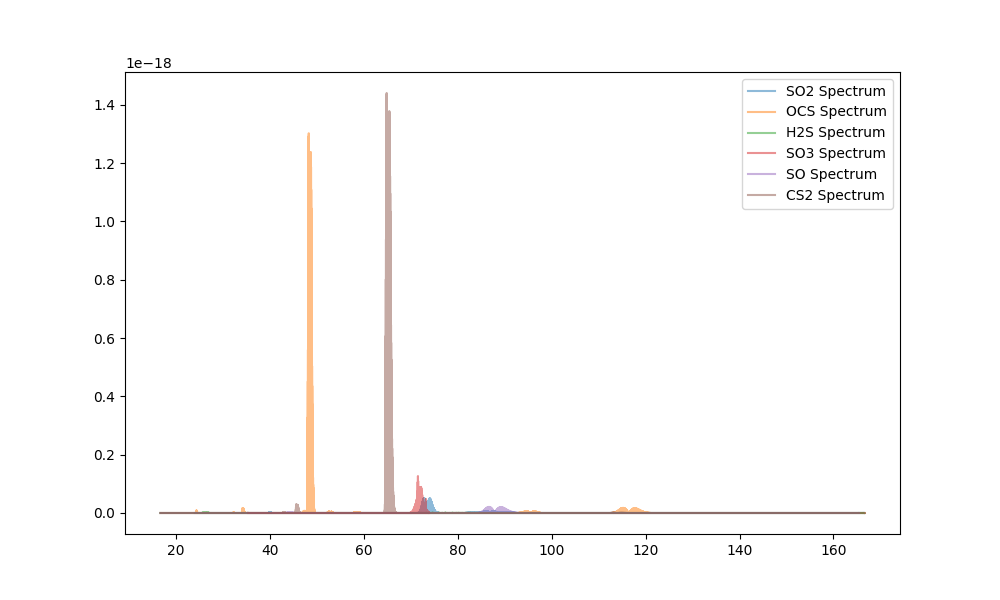

In [54]:
plt.figure(figsize=(10,6))

for i in range(len(molecule_number_dict)):
    # print(i, list(molecule_number_dict.keys())[i], molecule_number_dict[list(molecule_number_dict.keys())[i]])
    x, y, = getStickXY(list(molecule_number_dict.keys())[i])
    plt.plot(10e4/x, y, label = f'{list(molecule_number_dict.keys())[i]} Spectrum', alpha=0.5)

# plt.set_xlabel("Wavenumber (cm$^{-1}$)")
# plt.set_ylabel("Transmittance")
plt.legend()
plt.show()

# eh

In [ ]:


# text_files= [
#         os.path.join(data_path, fname)
#     for fname in molecule_number_dict
#     if fname.endswith('.txt') or fname.endswith('.xsc.txt') or fname.endswith('.data')
# ]
# Spreadsheet with biosginature indicator (parsing commented out for now)

# asm_df = pd.read_excel('/users/ZaniacCollins/Desktop/VenusProject/sgl/ASM_5.0_release.xlsx')
# asm_df['Name'] = asm_df['Unnamed: 4'].str.strip()
# asm_df['Unnamed: 13'] = asm_df['Unnamed: 13'].str.upper().str.strip()
# life_dict = dict(zip(asm_df['Unnamed: 4'], asm_df['Unnamed: 4']))
# all_files = sorted(glob.glob(os.path.join(data_path, "*.txt")))

#Extracting names

# all_files = sorted(glob.glob(os.path.join(data_path, "*.txt")))
# molecule_file_info = [(file, extract_name(file)) for file in all_files]

# pairs = [(extract_name(f), f) for f in text_files]
# Sort alphabetically by molecule name
# pairs.sort(key=lambda x: x[0])

# text_files_sorted = [f for name, f in pairs]
# molecule_names_sorted = [name for name, f in pairs]

# Sort files and molecule names according to biosignature indicator commented out for now
# used_by_life = []
# not_used_by_life = []
# not_listed = []
# for file, mol in molecule_file_info:
#     if mol in life_dict:
#         if life_dict[mol] == 'Y':
#             used_by_life.append((file, mol))
#         else:
#             not_used_by_life.append((file, mol))
#     else:
#         not_listed.append((file, mol))

# Combine with order: life, not life, unlisted
# life_ordered_files = used_by_life + not_used_by_life + not_listed

# Unpack sorted names and files if you want separate lists again
# text_files_sorted = [file for file, mol in life_ordered_files]
# molecule_names_sorted = [mol for file, mol in life_ordered_files]

# Parameters
num_molecules = len(molecule_number_dict)  # Keep manageable...update to as needed
wavelength = np.linspace(wavelength_min, wavelength_max, wavelength_bins)  # Wavelength in microns
# molecule_names = molecule_names_sorted
spectra = []

# List of target molecules and their custom colormaps
target_molecules = {
    "methanethiol": plt.colormaps["Greens"],
    "dimethylsulfide": plt.colormaps["Greens"],
    "dimethyldisulfide": plt.colormaps["Greens"],
    "carbondisulfide": plt.colormaps["Greens"],
    "carbonylsulfide": plt.colormaps["Greens"],
}

# #Line-by-line or not??
# line_by_line = True

# for i,(name, number) in enumerate(molecule_number_dict.items()):
#     if line_by_line == True:
#         generate_spectrum_hapi(name, number, wavelength_min, wavelength_max)
#         lam, intensity = load_intensity_hapi(name)
#     # else:
#     #     wn_start, wn_end, intensity = get_wn_range_and_intensities(file)
#     #     wn_grid = np.linspace(wn_start, wn_end, len(intensity))
#     #     wn_grid = wn_grid[wn_grid!= 0]
#     #     lam = 1e4 / wn_grid
#     # Ensure monotonic increasing for interpolation
#     min_log_intensity, max_log_intensity = custom_log_y_limits[i]
#     sort_idx = np.argsort(lam)
#     lam = lam[sort_idx]
#     intensity = intensity[sort_idx]
#     intensity = np.clip(intensity, 1*10^min_log_intensity, None)
#     log_intensity = np.log10(intensity)

#         # --- Per-spectrum log-intensity limits ---
    
#     if min_log_intensity is None:
#         min_log_intensity = np.min(log_intensity)
#     if max_log_intensity is None:
#         max_log_intensity = np.max(log_intensity)
#     log_intensity = np.clip(log_intensity, min_log_intensity, max_log_intensity)
#     interp_log_intensity = np.interp(wavelength, lam, log_intensity)
#     offset = -min_log_intensity
#     interp_log_intensity += offset

#     # Mask outside real spectrum range
#     lam_min, lam_max = min(lam), max(lam)
#     interp_log_intensity = np.where(
#         (wavelength >= lam_min) & (wavelength <= lam_max),
#         interp_log_intensity,
#         min(interp_log_intensity)
#     )
#     print(f"{name}: min={np.min(log_intensity)}, max={np.max(log_intensity)}, lam_min={np.min(lam)}, lam_max={np.max(lam)}")
#     spectra.append(interp_log_intensity)



In [ ]:
spectra = []

custom_log_y_limits = []
for i in range(num_molecules):
    custom_log_y_limits.append((-22,-10))

for i,(name, number) in enumerate(molecule_number_dict.items()):
    
    generate_spectrum_hapi(name, number, wavelength_min, wavelength_max)
    lam, intensity = load_intensity_hapi(name)

    min_log_intensity, max_log_intensity = custom_log_y_limits[i]
    sort_idx = np.argsort(lam)
    lam = lam[sort_idx]
    intensity = intensity[sort_idx]
    intensity = np.clip(intensity, 1*10**min_log_intensity, None)
    log_intensity = np.log10(intensity)

        # --- Per-spectrum log-intensity limits ---
    
    if min_log_intensity is None:
        min_log_intensity = np.min(log_intensity)
    if max_log_intensity is None:
        max_log_intensity = np.max(log_intensity)
    log_intensity = np.clip(log_intensity, min_log_intensity, max_log_intensity)
    interp_log_intensity = np.interp(wavelength, lam, log_intensity)
    offset = -min_log_intensity
    interp_log_intensity += offset

    # Mask outside real spectrum range
    lam_min, lam_max = min(lam), max(lam)
    interp_log_intensity = np.where(
        (wavelength >= lam_min) & (wavelength <= lam_max),
        interp_log_intensity,
        min(interp_log_intensity)
    )
    print(f"{name}: min={np.min(log_intensity)}, max={np.max(log_intensity)}, lam_min={np.min(lam)}, lam_max={np.max(lam)}")
    spectra.append(interp_log_intensity)



Data is fetched from http://hitran.org

BEGIN DOWNLOAD: SO2
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes written to HAPI_DB/SO2.data
  65536 bytes w

# Plotting

NameError: name 'num_molecules' is not defined

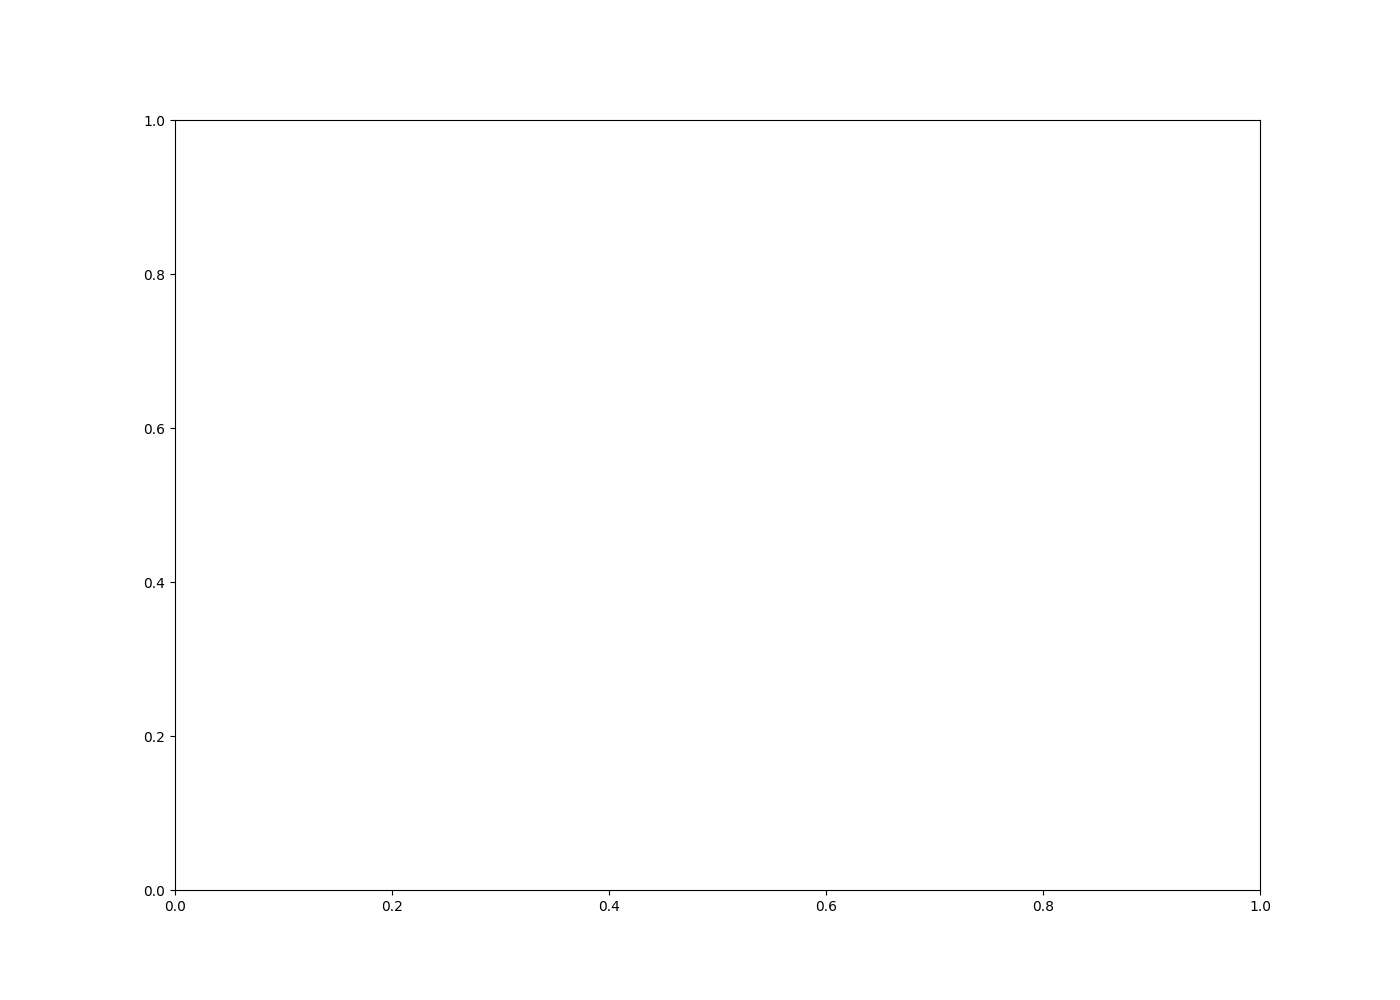

In [3]:

# Plotting
fig, ax = plt.subplots(figsize=(14, 10)) # can make this larger if needed
offset = 1.5  # Vertical offset between spectra, adjust as needed
colors = cm.Oranges(np.linspace(1.5, 10.0, num_molecules))
colormaps = [
    plt.colormaps["Oranges"],
    plt.colormaps["Blues"],
    plt.colormaps["Greens"],
    plt.colormaps["Reds"],
]



# # Define custom red-to-orange colormap
# red_orange_cmap = LinearSegmentedColormap.from_list(
#     "RedOrangeSmooth",
#     [
#         # "#fffaf5",  # very light
#         "#ffe3c2",  # light orange
#         "#ffb573",  # orange
#         "#ff963a",  # deep orange
#         "#ff5d00",  # vivid orange
#         "#ff3000",  # red-orange
#         "#c41c00"   # deep red
#     ],
#     N=100  # More steps for a smoother gradient
# )

# This colormap is the most similar to the one used in the paper
red_orange_cmap = LinearSegmentedColormap.from_list(
    "RedOrangeSmooth",
    [
        "#fffbf5",  
        "#ffe7ce",  
        "#ffc587", 
        "#ffb058",  
        "#ffa233", 
        "#ff9701", 
        "#ff7f00",
        "#ff7200",
        "#ff5800",
        "#ff4900",
        "#ff4400",
        "#ff3b00",
        "#ff2a00",
        "#ff3600"
    ],
    N=500  # More steps for a smoother gradient
)

use_fill = False  # <-- Set this to False for line-only mode

for i, (spectrum, mol_name) in enumerate(zip(spectra, molecule_number_dict.keys())):
    x = wavelength
    y = spectrum - i * offset
    
    # Pick colormap for this molecule
    cmap = get_colormap(mol_name.lower().replace(" ", ""))

    # Draw baseline
    ax.plot(x, np.full_like(x, -i * offset), color='white', linewidth=0.7, zorder=0)
    avg_y = (y[:-1] + y[1:]) / 2
    n_shades = 500
    min_y = np.min(y)
    max_y = np.max(y)
    frac = (avg_y - min_y) / (max_y - min_y)
    darker_frac = 0.5 + 0.5 * frac  # Maps [0,1] → [0.5,1]

    # Gradient fill from bottom (min_y) to curve
    n_shades = 500
    min_y = np.min(y)
    max_y = np.max(y)
    norm = Normalize(min_y, max_y)
    y_shades = np.linspace(min_y, max_y, n_shades)

    # Create line segments from the curve to the baseline
    segments = []
    colors = []

    for y0, y1 in zip(y_shades[:-1], y_shades[1:]):
        # Mask to get part of curve between y0 and y1
        y_fill = np.clip(y, y0, y1)

        # Fractional height between min_y and max_y
        frac = (y1 - min_y) / (max_y - min_y) # stronger at top

        # Interpolate color from colormap (higher intensity near top)
        # color = cmap(0 + 0.85 * frac)  # Adjust this if you want to clip off part of the color map...shouldn't be necessary 
        color = cmap(frac)

        # Shade in the spectral peaks
        ax.fill_between(x, y0, y_fill, color=color, edgecolor=None, alpha = 1, zorder = i)

        # Add labels for each molecule
        #ax.text(0.1, -i * offset, molecule_names[i], va='center', ha='right', fontsize=7)

    # Plot the curve as a gradient-colored outline
    # Could play around with this to make it a little darker than the shading
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    avg_y = (y[:-1] + y[1:]) / 2
    frac = (avg_y - min_y) / (max_y - min_y)

    colors = cmap(frac)

    lc = LineCollection(segments, colors=colors, linewidths=1.2, zorder = i)
    ax.add_collection(lc)

# Set y-ticks at the baseline of each spectrum
ytick_positions = [-i * offset for i in range(num_molecules)]
ax.set_yticks(ytick_positions)
ax.set_yticklabels(molecule_number_dict[i],  fontsize = 8)
ax.set_ylabel("Molecule")


wavelength_ticks=[]
wavelength_min = float(np.min(wavelength))
wavelength_max = float(np.max(wavelength))
num_ticks = 5
wavelength_ticks = np.linspace(wavelength_min, wavelength_max, num_ticks)


# Axes setup
ax.set_xlim(1.5, 13)
ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Log(Cross-Section Absorption) + offset")
ax.set_xticks(wavelength_ticks)

# Add top axis for wavenumber
def micron_to_wavenumber(x): return 1e4 / x
def wavenumber_to_micron(x): return 1e4 / x

secax = ax.secondary_xaxis('top', functions=(micron_to_wavenumber, wavenumber_to_micron))
secax.set_xlabel("Wavenumber (cm⁻¹)") # upper x-axis label
# Set the ticks for the secondary x-axis

secax.set_xticks(1e4/wavelength_ticks)

plt.tight_layout()
plt.show()

In [ ]:
print(molecule_number_dict)